## Import thư viện và khởi tạo OCR Engine

In [1]:
import sys
sys.path.insert(0, '..')

import os
import json
import glob
import matplotlib.pyplot as plt
from PIL import Image

from src.ocr.ocr_processor import PaddleOCRProcessor

# Khởi tạo OCR processor
ocr_processor = PaddleOCRProcessor(
    use_doc_orientation_classify=False,
    use_doc_unwarping=False,
    use_textline_orientation=False
)

c:\Users\Thach\miniconda3\envs\project\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Checking connectivity to the model hosters, this may take a while. To bypass this check, set `DISABLE_MODEL_SOURCE_CHECK` to `True`.


Đang khởi tạo PaddleOCR engine...


c:\Users\Thach\miniconda3\envs\project\lib\site-packages\paddle\utils\cpp_extension\extension_utils.py:718: UserWarning: No ccache found. Please be aware that recompiling all source files may be required. You can download and install ccache from: https://github.com/ccache/ccache/blob/master/doc/INSTALL.md
  warnings.warn(warning_message)
Creating model: ('PP-OCRv5_server_det', None)
Model files already exist. Using cached files. To redownload, please delete the directory manually: `C:\Users\Thach\.paddlex\official_models\PP-OCRv5_server_det`.
Creating model: ('PP-OCRv5_server_rec', None)
Model files already exist. Using cached files. To redownload, please delete the directory manually: `C:\Users\Thach\.paddlex\official_models\PP-OCRv5_server_rec`.


-> PaddleOCR đã sẵn sàng!


## Cấu hình đường dẫn

In [2]:
from src.utils.constant import *
from src.ocr.layout import *

Input folder: d:\Thach\HUST\Project_1\VQA\code\dataset\DocVQA_Images
Output folder: d:\Thach\HUST\Project_1\VQA\code\dataset\DocVQA_OCR


## Chọn 1 ảnh mẫu

Chạy OCR với Layout Analysis...

KẾT QUẢ LAYOUT ANALYSIS
Số lines: 28
Số blocks: 25
Số regions: 1

Regions phát hiện:
--------------------------------------------------------------------------------

1. Type: TEXT | Score: 0.665
   - Avg line length: 33.0
   - Spacing uniformity: 1.00


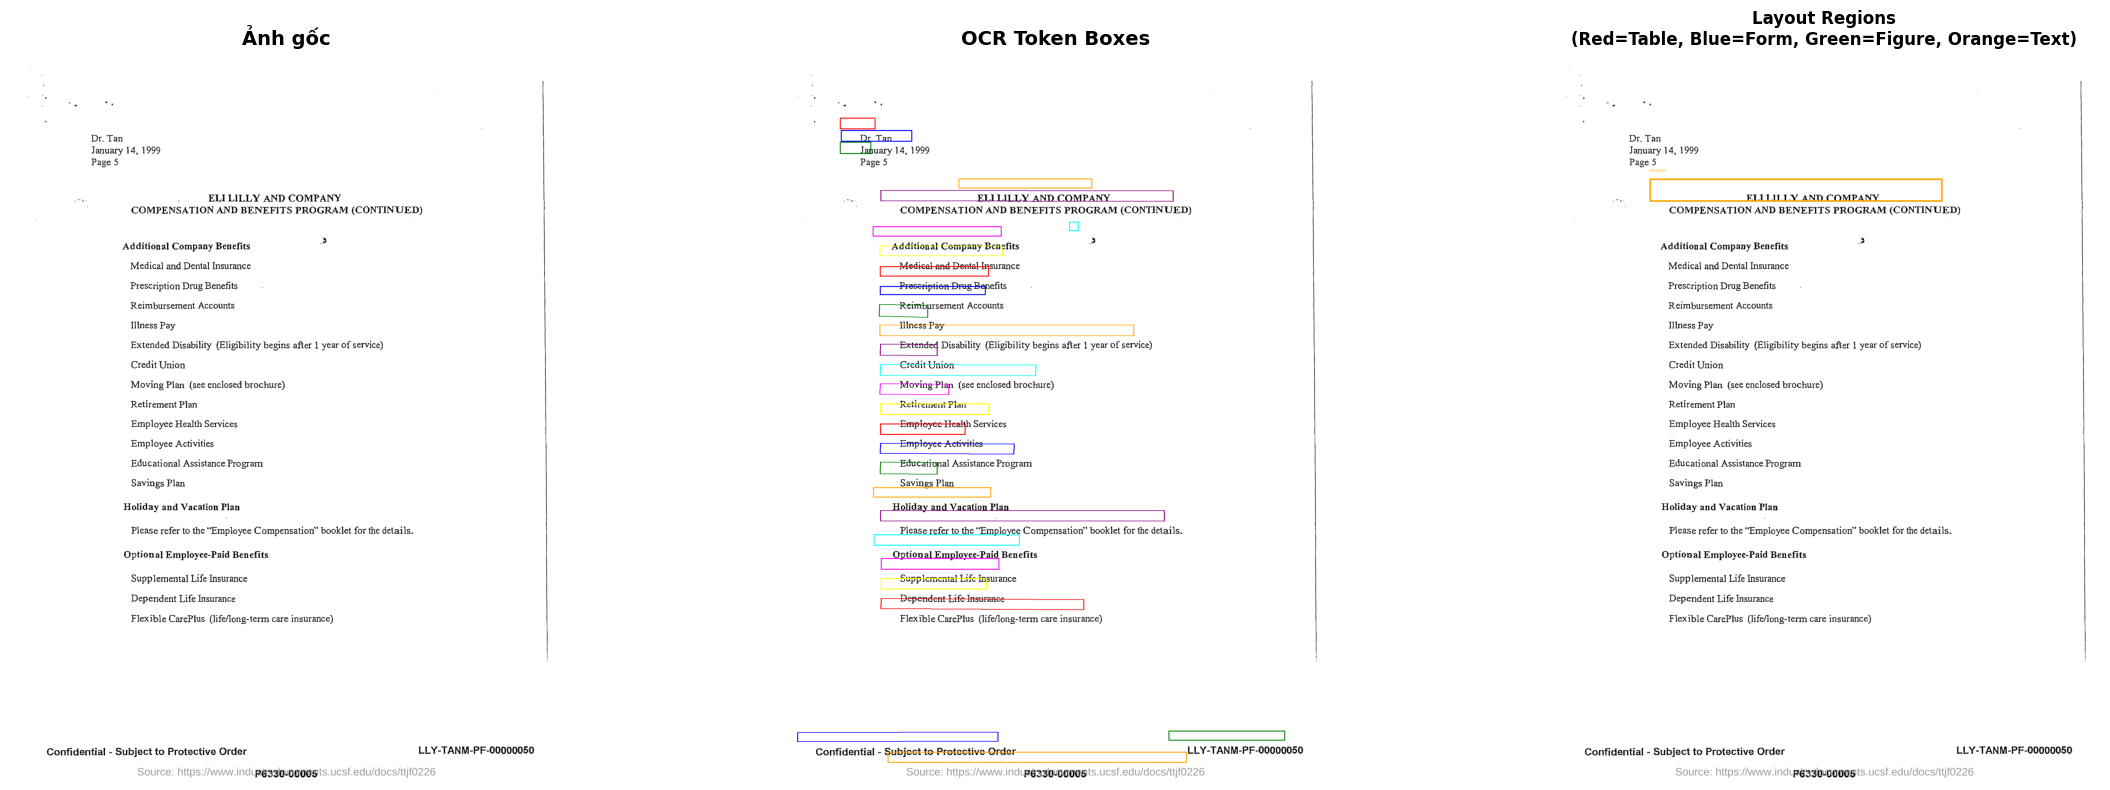


LEGEND - Region Colors:
  🔴 RED    = Table (bảng)
  🔵 BLUE   = Form (key:value)
  🟢 GREEN  = Figure (chart/plot)
  🟠 ORANGE = Text (đoạn văn)
  🟣 PURPLE = Layout (multi-column/heading)

TEXT CONTENT THEO TỪNG REGION

────────────────────────────────────────────────────────────────────────────────
📋 TEXT REGIONS (1 phát hiện)
────────────────────────────────────────────────────────────────────────────────

[TEXT #1] Score: 0.665
────────────────────────────────────────
 1. ELI LILLY AND COMPANY
 2. COMPENSATION AND BENEFITS PROGRAM (CONTINUED)


In [3]:
# Tìm 1 ảnh mẫu
import random

sample_image = '../dataset/DocVQA_Images\\train\\1037.png'
idx = random.randint(0, 1000)
if sample_image is None:
    for subset in SUBSETS:
        subset_folder = os.path.join(IMAGES_FOLDER, subset)
        if os.path.exists(subset_folder):
            images = glob.glob(os.path.join(subset_folder, "*.png"))[idx:idx+1]
            print(images)
            if images:
                sample_image = images[0]
                break
else:
    images = os.path.join(IMAGES_FOLDER, 'train', f'{sample_image}.png')
    
group(sample_image, ocr_processor)

---
## Document Layout Analysis

Phân tích cấu trúc document sau khi OCR:
- **Stage I**: Group token → line → block
- **Stage II**: Detect regions (table, form, figure, text, layout)

## Visualize Stage I Groups

Hiển thị các bước grouping ở Stage I:
- **Token**: Các bounding box từ OCR
- **Line**: Gộp tokens thành lines
- **Block**: Gộp lines thành blocks

Chạy OCR với Layout Analysis...


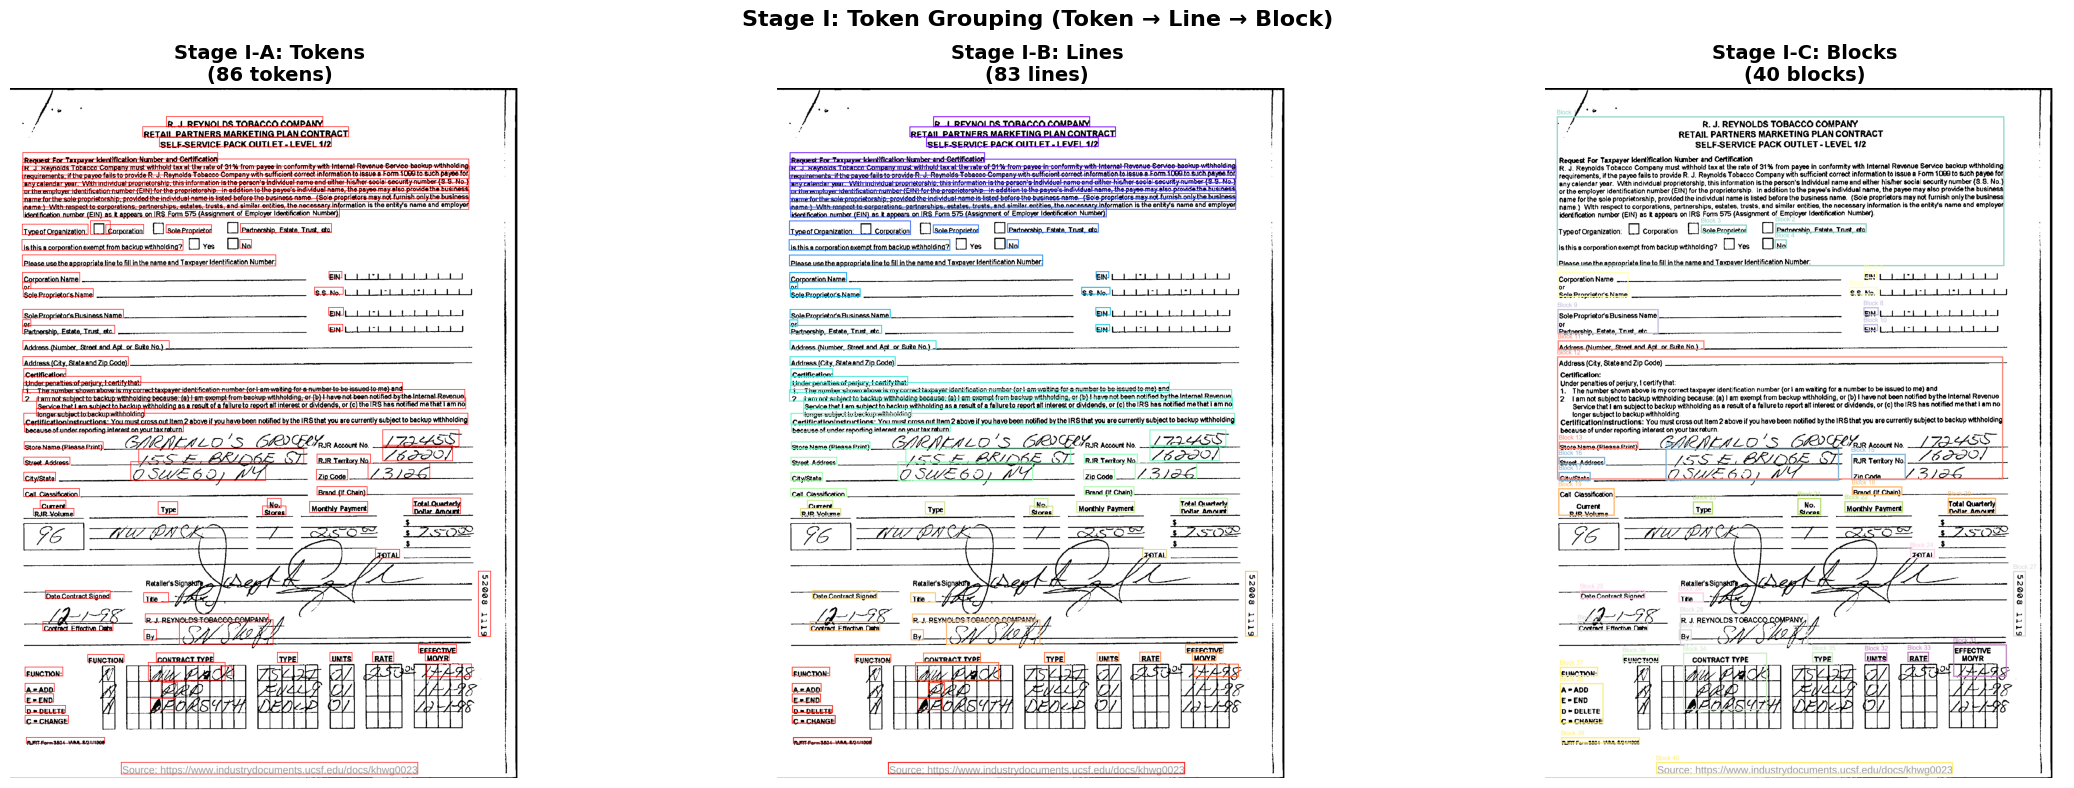


STAGE I - TOKEN GROUPING STATISTICS
Tokens: 86
Lines:  83
Blocks: 40



{'text': "R. J. REYNOLDS TOBACCO COMPANY RETAIL PARTNERS MARKETING PLAN CONTRACT SELF-SERVICE PACK OUTLET-LEVEL 1/2 Request For Taxpayer IdentHication Number and Certification R. j.Reynolds Tobacco Company must withhold tax at the rate of 31% from payee in conformity with Internal Revenue Service backup withholding requirements,if the payee fails to provide R.J.Reynolds Tobacco Company with sufficient correct information to issuea Form1g to such payee for anycalendar year. With individual proprietorshlp.this information isthe person's individual name and either hisher social security number (S.S.No.) or the employer identification number (EiN) for the proprietorship.In addition to the payee's individual name,the payee may also providethe business name for the sole proprietorship. provided the individual name is listed before the business name. (Sole proprletors may not furnish only the business name.) With respect to corporations, partnerships,estates, trusts,and similar entities, the 

In [5]:
visualize_stage1_groups(sample_image, ocr_processor)

---
## Semantic Layout Graph Visualization

Build and visualize semantic layout graph from detected regions

### Import Graph Visualization Utilities

In [6]:
from src.graph.graph_builder import GraphBuilder
from src.utils.graph_viz import *

print("✅ Graph visualization utilities imported")

✅ Graph visualization utilities imported


### Build Semantic Layout Graph

In [7]:
# Configure graph builder
graph_builder = GraphBuilder(
    iou_threshold=0.1,
    distance_threshold=200.0,
    projection_threshold=0.3,
    max_neighbors=5,
    min_edge_score=0.2
)

# Get regions from OCR result
ocr_result = ocr_processor.run_ocr_with_layout(
    sample_image,
    use_preprocessing=True,
    max_size=2500
)

if ocr_result.get('success') and ocr_result.get('layout'):
    regions = ocr_result['layout'].get('regions', [])
    
    # Build the graph
    graph_result = graph_builder.build_graph(regions)
    
    nodes = graph_result['nodes']
    edges = graph_result['edges']
    adjacency = graph_result['adjacency']
    
    print(f"\n{'='*60}")
    print(f"📊 GRAPH BUILDING RESULTS")
    print(f"{'='*60}")
    print(f"Total Nodes: {len(nodes)}")
    print(f"Total Edges: {len(edges)}")
    
    # Group edges by relation type
    relation_counts = {}
    for edge in edges:
        rel_type = edge['relation']
        relation_counts[rel_type] = relation_counts.get(rel_type, 0) + 1
    
    print(f"\nEdges by Relation Type:")
    print(f"-" * 60)
    for rel_type, count in sorted(relation_counts.items(), key=lambda x: x[1], reverse=True):
        print(f"  {rel_type:20s}: {count:3d} edges")
    
    # Group by category
    category_counts = {}
    for edge in edges:
        cat = edge.get('category', 'unknown')
        category_counts[cat] = category_counts.get(cat, 0) + 1
    
    print(f"\nEdges by Category:")
    print(f"-" * 60)
    for cat, count in sorted(category_counts.items(), key=lambda x: x[1], reverse=True):
        print(f"  {cat:15s}: {count:3d} edges")
    
    print(f"{'='*60}\n")
else:
    print("❌ Failed to get layout regions")
    regions = []
    nodes = []
    edges = []


📊 GRAPH BUILDING RESULTS
Total Nodes: 4
Total Edges: 10

Edges by Relation Type:
------------------------------------------------------------
  above               :   5 edges
  below               :   5 edges

Edges by Category:
------------------------------------------------------------
  spatial        :  10 edges



### Visualize Graph - All Nodes and Edges

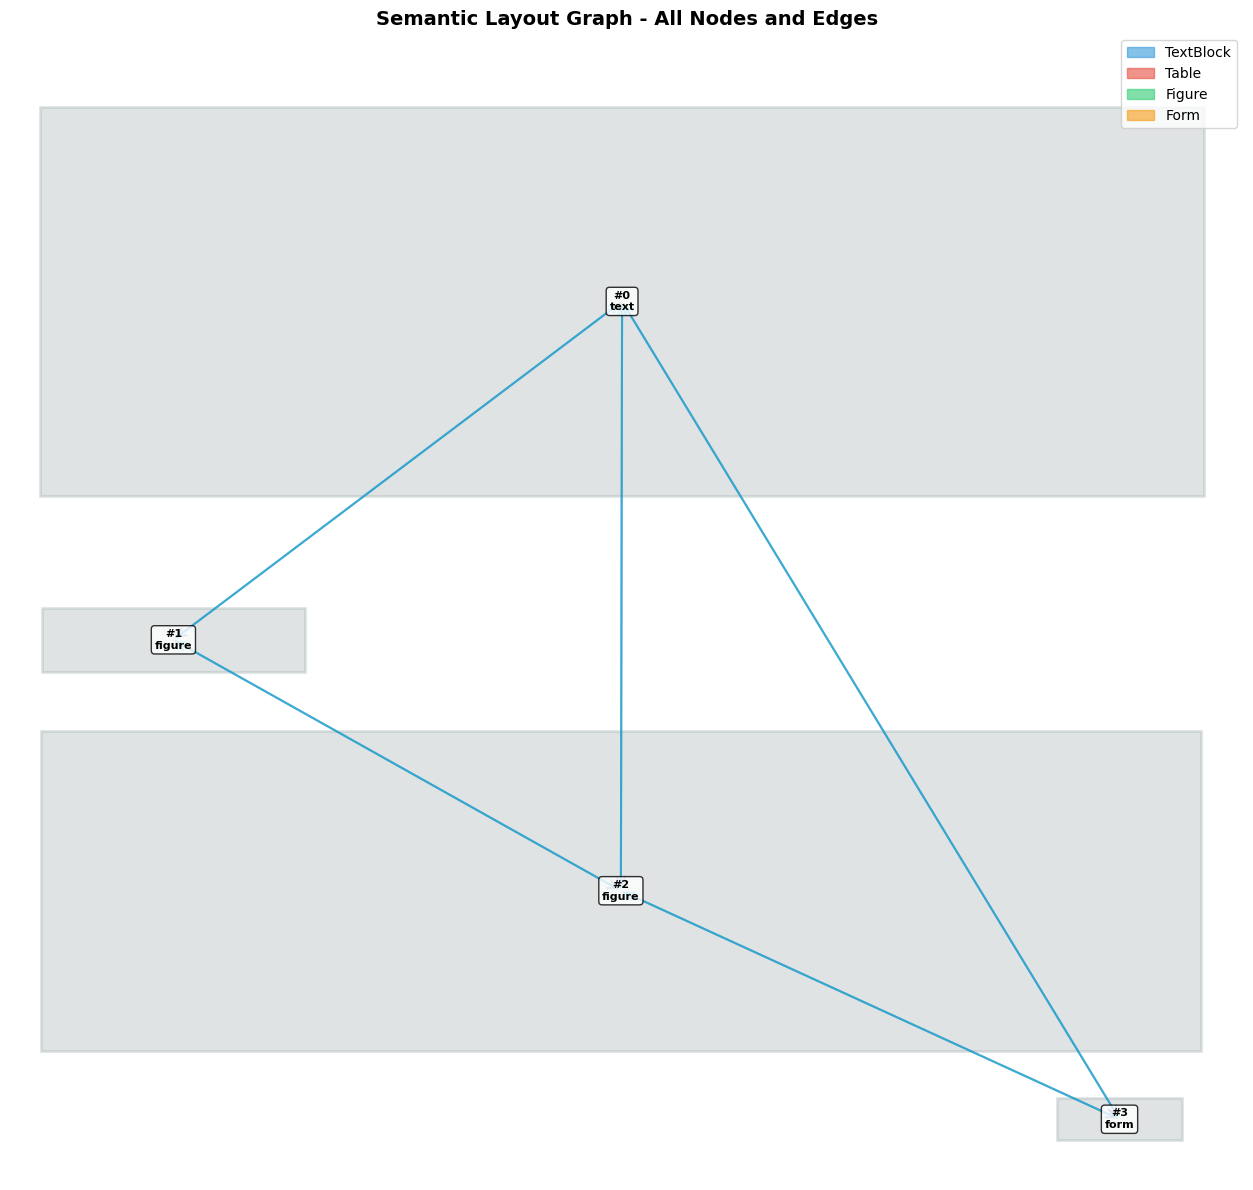

In [8]:
if nodes and edges:
    visualize_graph_basic(nodes, edges, figsize=(16, 12))
else:
    print("⚠️ No graph to visualize")

### Visualize by Relation Type

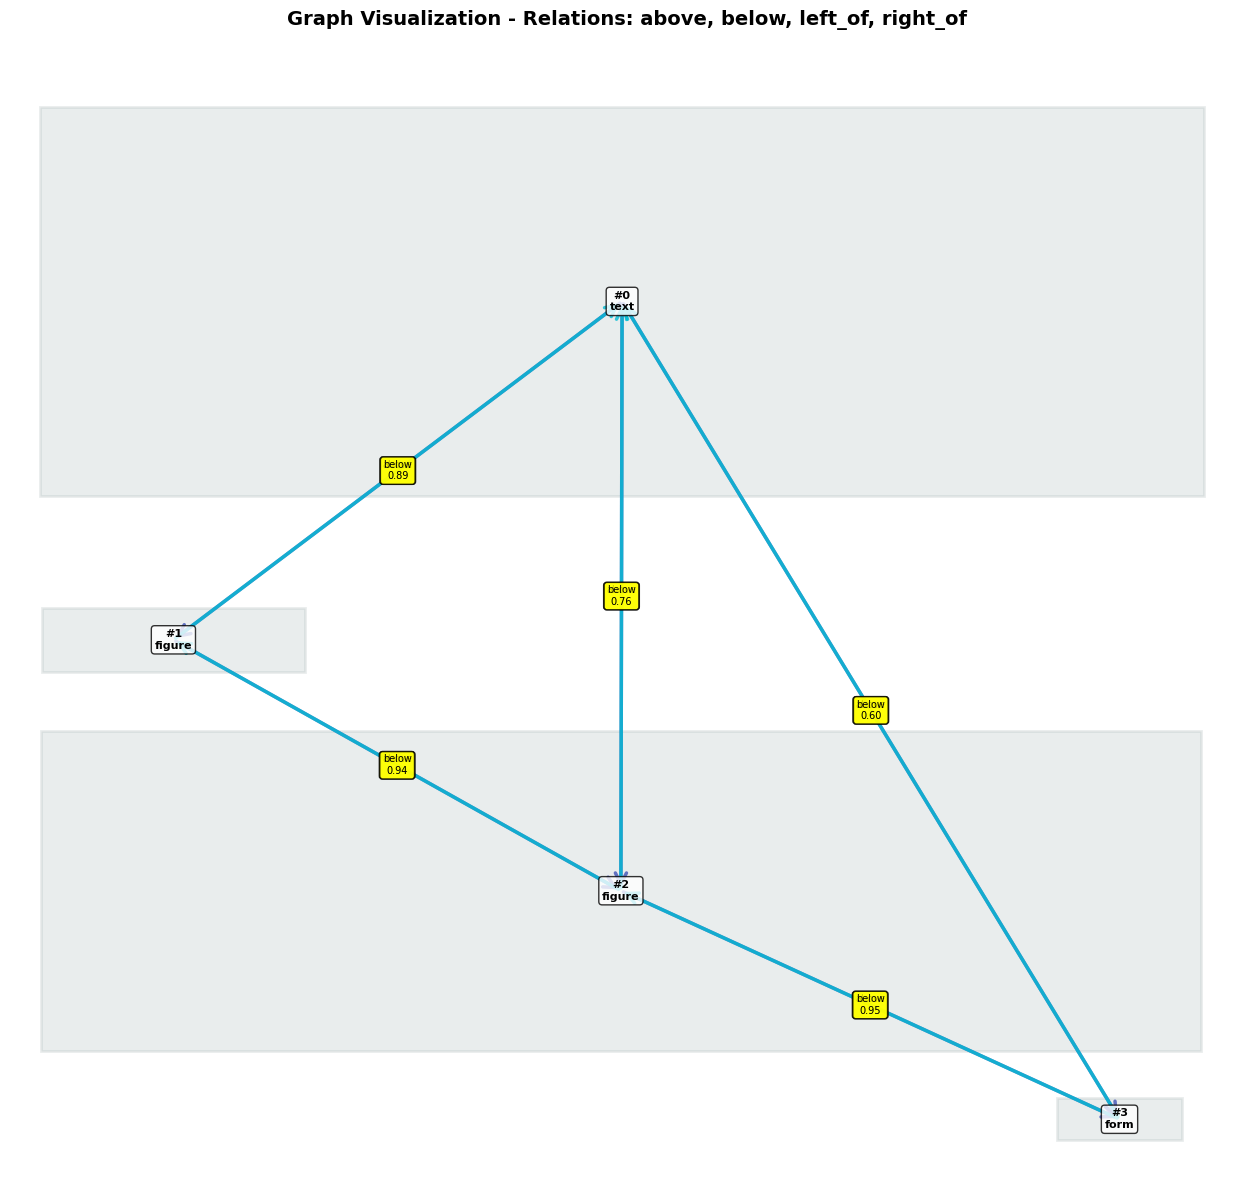

Showing 10 edges of type(s): ['above', 'below', 'left_of', 'right_of']


In [9]:
if nodes and edges:
    # Visualize spatial relations
    visualize_by_relation_type(nodes, edges, ['above', 'below', 'left_of', 'right_of'], figsize=(16, 12))
else:
    print("⚠️ No graph to visualize")

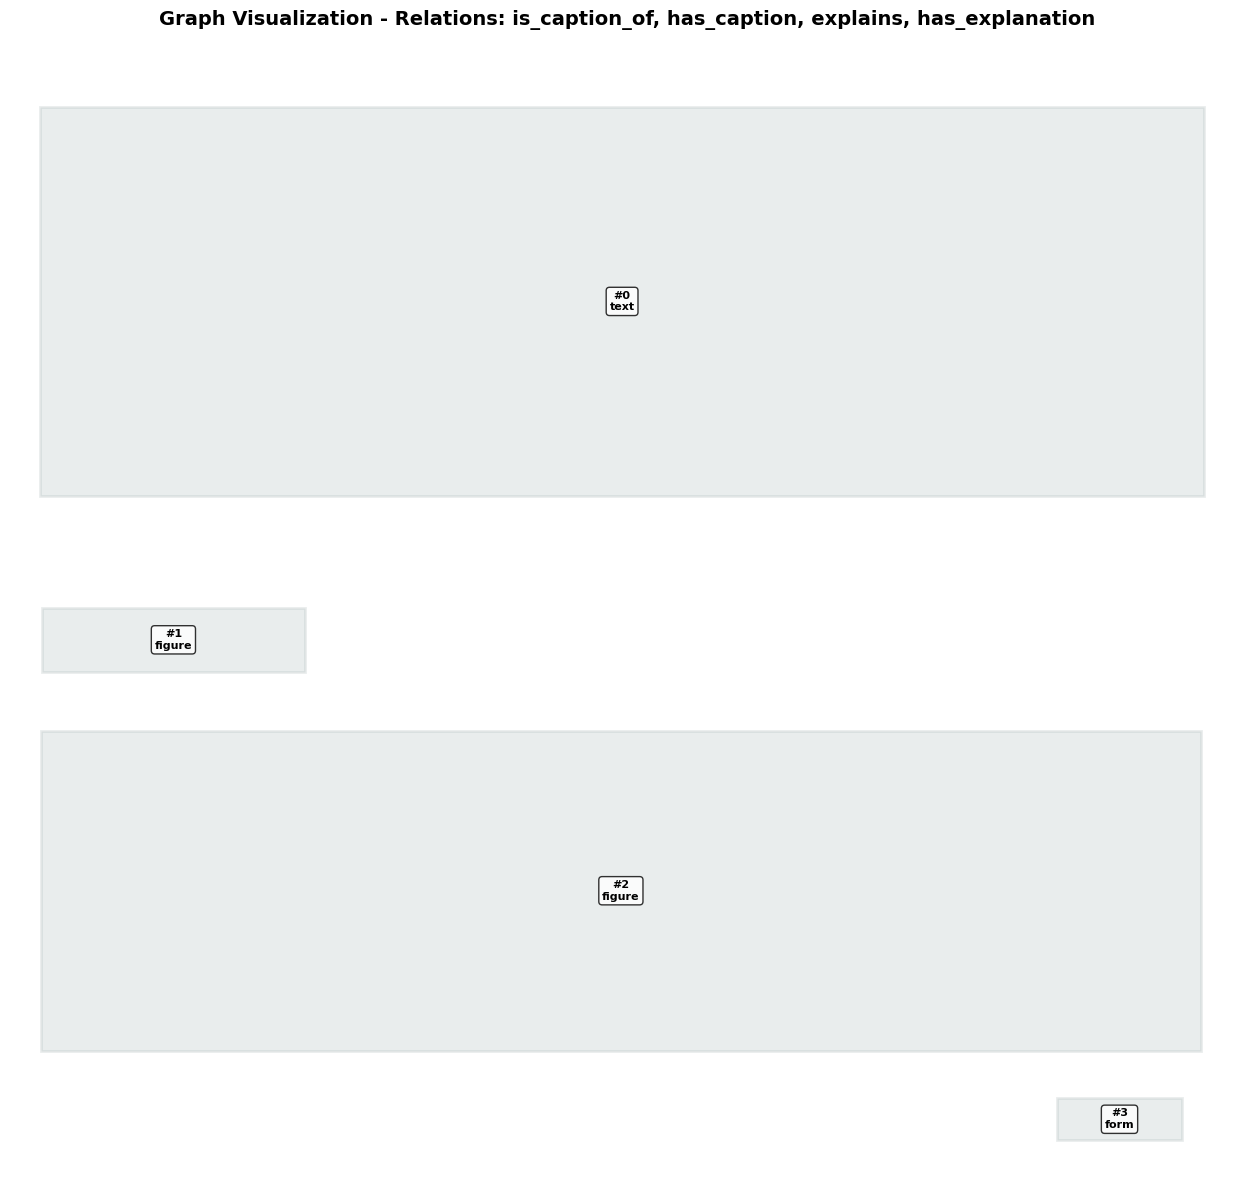

Showing 0 edges of type(s): ['is_caption_of', 'has_caption', 'explains', 'has_explanation']


In [10]:
if nodes and edges:
    # Visualize semantic relations
    visualize_by_relation_type(nodes, edges, ['is_caption_of', 'has_caption', 'explains', 'has_explanation'], figsize=(16, 12))
else:
    print("⚠️ No graph to visualize")

### Graph Statistics and Analysis


TOP 10 EDGES BY SCORE

 1. [above] Score: 0.952 (spatial)
    Source #2 (figure): Address (City. Stateand Zip Code) Certificatlon: U...
    Target #3 (form): Total Quarterly Dollar Amount...

 2. [below] Score: 0.952 (spatial)
    Source #3 (form): Total Quarterly Dollar Amount...
    Target #2 (figure): Address (City. Stateand Zip Code) Certificatlon: U...

 3. [above] Score: 0.941 (spatial)
    Source #1 (figure): Sole Proprietor'sBusiness Name or Partnership, Est...
    Target #2 (figure): Address (City. Stateand Zip Code) Certificatlon: U...

 4. [below] Score: 0.941 (spatial)
    Source #2 (figure): Address (City. Stateand Zip Code) Certificatlon: U...
    Target #1 (figure): Sole Proprietor'sBusiness Name or Partnership, Est...

 5. [above] Score: 0.888 (spatial)
    Source #0 (text): R. J. REYNOLDS TOBACCO COMPANY RETAIL PARTNERS MAR...
    Target #1 (figure): Sole Proprietor'sBusiness Name or Partnership, Est...

 6. [below] Score: 0.888 (spatial)
    Source #1 (figure): Sole 

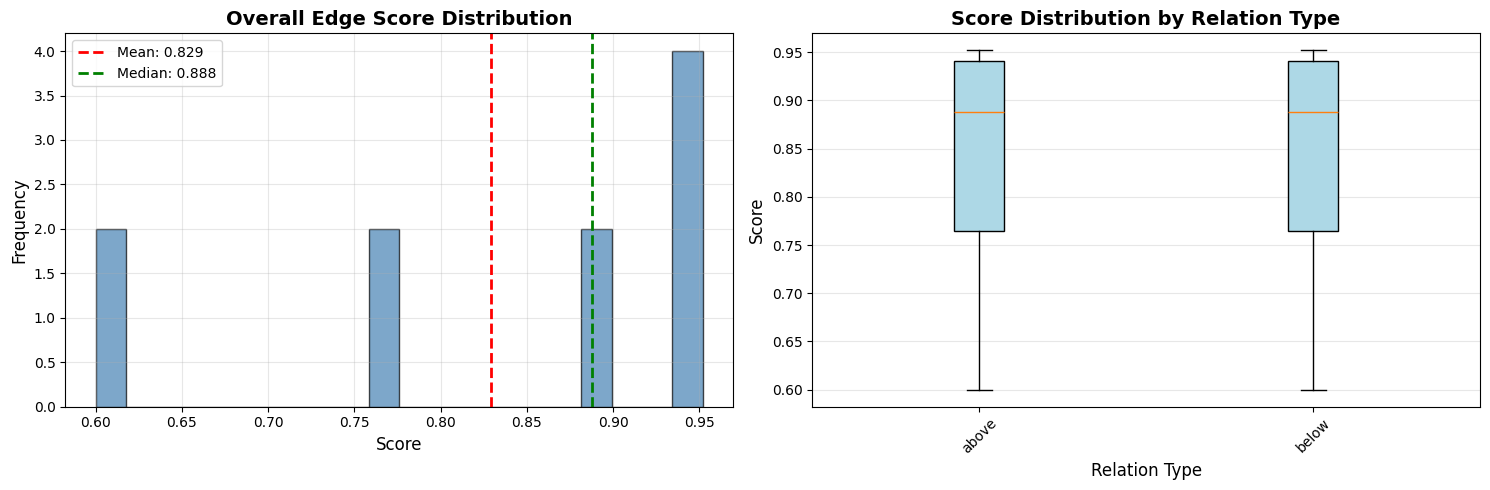

In [11]:
if nodes and edges:
    # Print detailed edge information
    print_edge_details(nodes, edges, top_n=10)
    
    # Analyze statistics
    analyze_graph_statistics(nodes, edges)
    
    # Plot score distributions
    plot_score_distributions(edges)
else:
    print("⚠️ No graph to analyze")

### Export Graph to JSON

In [12]:
if nodes and edges:
    import os
    output_path = os.path.join('..', 'output', 'graph_visualization_output.json')
    
    export_graph_to_json(
        graph_result=graph_result,
        output_path=output_path,
        metadata={
            'source_image': os.path.basename(sample_image),
            'num_regions': len(regions),
            'num_nodes': len(nodes),
            'num_edges': len(edges)
        }
    )
else:
    print("⚠️ No graph to export")

✅ Graph exported to: ..\output\graph_visualization_output.json

Exported data structure:
  - Nodes: 4
  - Edges: 10
  - Adjacency entries: 4
